# Data Center Load Forecast & Rate Impact Model — Dominion (DOM) zone

**How to run:** fill in the **Settings** cell, then use **Kernel → Restart Kernel and Run All Cells** (Jupyter Lab) or **Kernel → Restart & Run All** (classic Jupyter).

1. **First time:** leave `SYNTHETIC = True`. The whole notebook then runs on **fake data**, so you can confirm everything works. You don't need an API key for this.
2. **Real run:** set `SYNTHETIC = False`, paste your EIA API key, fill in the three input CSVs (the *Check inputs* step creates blank templates), and run all again.

Charts appear under each step and are also saved as PNGs. Tables are saved as CSVs, plus one Excel workbook:

| | Fake data | Real data |
|---|---|---|
| Tables | `outputs_synthetic/tables/` | `outputs/tables/` |
| Charts | `outputs_synthetic/figures/` | `outputs/figures/` |
| Excel | `model_synthetic/` | `model/` |

All folders are created next to this notebook. Every assumption marked **VERIFY** in the Assumptions cell is a placeholder. Source each one before you use any results in a report.

## 0. Install packages
Installs into the same Python this notebook is running on. Run it once, then **restart the kernel** if anything was newly installed.

In [19]:
%pip install -q pandas numpy statsmodels holidays pyyaml matplotlib pyarrow openpyxl requests

Note: you may need to restart the kernel to use updated packages.


## Settings

In [20]:
SYNTHETIC = True        # True = fake test data (run this first).  False = real data.
EIA_API_KEY = ""        # free key: https://www.eia.gov/opendata/register.php  (only needed when SYNTHETIC = False)

## Imports

In [21]:
import copy, os, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline
pd.set_option("display.width", 200, "display.max_columns", 30)

ROOT = Path.cwd()   # the folder this notebook is in
print("Working folder:", ROOT)

Working folder: /Users/opdime/Projects/dominionenergy_forecast


## Assumptions
Edit values here. Anything marked **VERIFY** is a placeholder that needs a source before you report it.

In [22]:
DEFAULT_CONFIG = {
    # --- run mode ---
    "synthetic_mode": False,              # true = use generated placeholder data (smoke tests only)
    "anchor_to_base_year": True,          # rescale baseline so base-year organic peak matches peak_base_2024_mw
    "exclude_energized_from_overlay": True,  # energized MW already in dc_historical_connected_mw.csv
    # --- data sources ---
    "eia_api_key": "YOUR_EIA_KEY",        # free key: https://www.eia.gov/opendata/register.php
    "eia_route": "electricity/rto/region-sub-ba-data",   # EIA-930 sub-BA hourly demand
    "eia_facets": {"parent": ["PJM"], "subba": ["DOM"]},  # Dominion zone of PJM
    "load_start": "2019-01-01T00",
    "load_end": "2025-12-31T23",
    "weather_stations": {                 # name: [lat, lon, population weight]  VERIFY weights
        "IAD_NoVA": [38.95, -77.45, 0.45],
        "RIC_Richmond": [37.51, -77.32, 0.30],
        "ORF_Norfolk": [36.90, -76.19, 0.25],
    },
    # --- horizon / baseline ---
    "base_year": 2024,
    "horizon_start": 2025,
    "horizon_end": 2035,
    "train_end_year": 2023,
    "test_start_year": 2024,
    "degree_day_base_f": 65,
    "peak_base_2024_mw": 22000,           # VERIFY weather-normalized DOM zone summer peak
    "energy_base_2024_gwh": 110000,       # VERIFY DOM zone annual energy
    # --- data center assumptions ---
    "dc_load_factor": 0.80,               # VERIFY average / peak for data centers
    "dc_pue_default": 1.30,               # grid MW = IT MW x PUE when only IT MW is reported
    "stage_prob": {                       # VERIFY probability a project at this stage gets built
        "low":  {"announced": 0.10, "zoned": 0.25, "interconnection_request": 0.35, "esa_signed": 0.65, "construction": 0.85, "energized": 1.0},
        "base": {"announced": 0.20, "zoned": 0.40, "interconnection_request": 0.50, "esa_signed": 0.80, "construction": 0.92, "energized": 1.0},
        "high": {"announced": 0.35, "zoned": 0.55, "interconnection_request": 0.65, "esa_signed": 0.90, "construction": 0.97, "energized": 1.0},
    },
    "stage_delay_median_yrs": {"announced": 2.0, "zoned": 1.5, "interconnection_request": 1.5, "esa_signed": 1.0, "construction": 0.5, "energized": 0.0},
    "stage_ramp_yrs": {"announced": 4, "zoned": 4, "interconnection_request": 3, "esa_signed": 3, "construction": 3, "energized": 1},
    "stage_delay_sigma": 0.5,
    "unannounced_mw_per_yr": {"low": 0, "base": 150, "high": 400},
    "unannounced_sd": 100,
    "mc_draws": 5000,
    "seed": 42,
    # --- supply / capital ---
    "prm": 0.17,                          # VERIFY PJM installed reserve margin
    "resource_shares": {"gas_cc": 0.55, "storage_4h": 0.20, "solar": 0.15, "smr_nuclear": 0.10},
    "elcc": {"gas_cc": 0.78, "storage_4h": 0.55, "solar": 0.10, "smr_nuclear": 0.95},          # VERIFY PJM ELCC class ratings
    "capex_per_kw": {"gas_cc": 2200, "storage_4h": 1800, "solar": 1500, "smr_nuclear": 10000},  # VERIFY 2024$/kW (EIA AEO / NREL ATB)
    "fom_per_kw_yr": {"gas_cc": 30, "storage_4h": 45, "solar": 22, "smr_nuclear": 130},         # VERIFY
    "book_life_yrs": {"gas_cc": 30, "storage_4h": 15, "solar": 30, "smr_nuclear": 60, "td": 45},
    "td_capex_per_kw_peak": 400,          # VERIFY transmission & distribution $/kW of new peak
    "marginal_energy_cost_per_mwh": 45,   # VERIFY
    "inflation": 0.025,
    # --- regulatory finance ---
    "equity_share": 0.52,                 # VERIFY Dominion VA capital structure
    "roe": 0.097,                         # VERIFY authorized ROE
    "tax_rate": 0.25,
    "cost_of_debt": 0.05,
    "ciac_share": 0.05,                   # share of capex paid upfront by customers (status quo)
    "tariff_ciac_share": 0.25,            # with a large-load tariff
    "rr_base_2024_usd": 9.0e9,            # VERIFY base-year revenue requirement
    # --- stranded-asset / tariff test ---
    "stranded_year": 2030,
    "stranded_share": 0.25,
    "demand_charge_per_kw_month": 12,
    "tariff_min_take": 0.85,
    # --- reporting ---
    "report_years": [2030, 2035],
}

## Constants & helper functions

In [23]:
STAGES = ["announced", "zoned", "interconnection_request", "esa_signed", "construction", "energized"]
STAGE_SYNONYMS = {
    "announced": "announced", "proposed": "announced", "planned": "announced", "rumored": "announced",
    "zoned": "zoned", "approved": "zoned", "rezoned": "zoned", "entitled": "zoned", "permitted": "zoned",
    "interconnection_request": "interconnection_request", "interconnection request": "interconnection_request",
    "under study": "interconnection_request", "under_study": "interconnection_request", "queue": "interconnection_request",
    "esa_signed": "esa_signed", "esa signed": "esa_signed", "contracted": "esa_signed", "esa": "esa_signed",
    "construction": "construction", "under construction": "construction", "under_construction": "construction",
    "energized": "energized", "operational": "energized", "online": "energized", "in service": "energized",
}
TECHS = ["gas_cc", "storage_4h", "solar", "smr_nuclear"]
PIPELINE_COLS = ["project_id", "campus_name", "developer", "tenant", "county", "state", "capacity_mw_it",
                 "capacity_mw_grid", "stage", "announced_date", "expected_cod", "source_url", "source_quote",
                 "source_date", "duplicate_of", "confidence", "notes"]


P = {}


def setup_paths(c):
    sfx = "_synthetic" if c["synthetic_mode"] else ""
    P.update({
        "raw": ROOT / f"data{sfx}/raw", "interim": ROOT / f"data{sfx}/interim", "proc": ROOT / f"data{sfx}/processed",
        "fig": ROOT / f"outputs{sfx}/figures", "tab": ROOT / f"outputs{sfx}/tables", "model": ROOT / f"model{sfx}",
    })
    for d in P.values():
        d.mkdir(parents=True, exist_ok=True)


def years(c):
    return list(range(c["horizon_start"], c["horizon_end"] + 1))


def savefig(name, title=None, source=None):
    if title:
        plt.title(title)
    if source:
        plt.figtext(0.01, 0.005, f"Source: {source}", fontsize=7, ha="left")
    plt.tight_layout()
    plt.savefig(P["fig"] / name, dpi=200)
    plt.show()          # display inline in the notebook


def mape(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    m = (y != 0) & ~np.isnan(y) & ~np.isnan(yhat)
    return float(np.mean(np.abs(yhat[m] - y[m]) / y[m]) * 100)


def ramp_fraction(year, cod, ramp_yrs):
    return float(np.clip((year + 1 - cod) / max(ramp_yrs, 1e-6), 0, 1))


def normalize_stage(s):
    if pd.isna(s):
        return None
    key = str(s).strip().lower().replace("-", "_")
    return STAGE_SYNONYMS.get(key, STAGE_SYNONYMS.get(key.replace("_", " ")))


def load_dc_series(years_needed):
    """Cumulative connected DC MW, reindexed to all needed years, interpolated and linearly extrapolated."""
    dc = pd.read_csv(P["raw"] / "dc_historical_connected_mw.csv")[["year", "dc_connected_mw"]]
    dc = dc.dropna().astype({"year": int, "dc_connected_mw": float}).drop_duplicates("year").set_index("year").sort_index()
    if len(dc) < 2:
        raise SystemExit("dc_historical_connected_mw.csv needs at least 2 years of data")
    full = pd.Index(range(min(dc.index.min(), min(years_needed)), max(dc.index.max(), max(years_needed)) + 1), name="year")
    s = dc.dc_connected_mw.reindex(full).interpolate(limit_direction="both")
    slope = (dc.dc_connected_mw.iloc[-1] - dc.dc_connected_mw.iloc[0]) / max(dc.index[-1] - dc.index[0], 1)
    for y in full:
        if y > dc.index.max():
            s[y] = dc.dc_connected_mw.iloc[-1] + slope * (y - dc.index.max())
        if y < dc.index.min():
            s[y] = max(dc.dc_connected_mw.iloc[0] - slope * (dc.index.min() - y), 0)
    return s.clip(lower=0)


def write_templates():
    """Create empty input templates for any missing real-data file."""
    made = []
    p = P["raw"] / "dc_historical_connected_mw.csv"
    if not p.exists():
        pd.DataFrame({"year": range(2018, 2026), "dc_connected_mw": np.nan, "source": "VERIFY", "source_url": "VERIFY",
                      "note": "cumulative connected data center MW at year end"}).to_csv(p, index=False)
        made.append(p)
    p = P["proc"] / "pipeline.csv"
    if not p.exists():
        pd.DataFrame([dict(project_id="P000", campus_name="EXAMPLE Campus (delete me)", developer="ExampleDev", tenant="",
                           county="Loudoun", state="VA", capacity_mw_it=np.nan, capacity_mw_grid=300, stage="zoned",
                           announced_date="2024-03-01", expected_cod=2028, source_url="VERIFY", source_quote="",
                           source_date="2024-03-01", duplicate_of="", confidence="medium", notes="")])[PIPELINE_COLS].to_csv(p, index=False)
        made.append(p)
    p = P["raw"] / "external_forecasts.csv"
    if not p.exists():
        pd.DataFrame(columns=["source", "vintage", "metric", "zone", "year", "value_mw", "url", "note"]).to_csv(p, index=False)
        made.append(p)
    for m in made:
        print(f"  template created: {m.relative_to(ROOT)} — fill it in")


def load_config():
    c = copy.deepcopy(DEFAULT_CONFIG)
    c["synthetic_mode"] = bool(SYNTHETIC)
    key = EIA_API_KEY or os.environ.get("EIA_API_KEY", "")
    if key:
        c["eia_api_key"] = key
    return c


c = load_config()
setup_paths(c)
print("Mode:", "SYNTHETIC (fake data)" if c["synthetic_mode"] else "REAL data", "| data folder:", P["raw"].parent)

Mode: SYNTHETIC (fake data) | data folder: /Users/opdime/Projects/dominionenergy_forecast/data_synthetic


## 1. Fake data (only when `SYNTHETIC = True`)

In [24]:
def step_synthetic(c):
    rng = np.random.default_rng(1)
    idx = pd.date_range(pd.Timestamp(c["load_start"][:10]), pd.Timestamp(c["load_end"][:10]) + pd.Timedelta(hours=23), freq="h")
    doy, hr, t = idx.dayofyear.values, idx.hour.values, (idx - idx[0]).days.values / 365.25
    temp_f = 57 + 22 * np.sin(2 * np.pi * (doy - 110) / 365) + 8 * np.sin(2 * np.pi * (hr - 9) / 24) + rng.normal(0, 4, len(idx))
    cdd, hdd = np.clip(temp_f - 65, 0, None), np.clip(65 - temp_f, 0, None)
    dc = 1500 + 650 * (idx.year.values - 2018)
    load = (11000 + 60 * cdd + 1.5 * cdd ** 2 + 35 * hdd + 0.6 * hdd ** 2 + 110 * t + c["dc_load_factor"] * dc
            + 1500 * np.sin(2 * np.pi * (hr - 17) / 24) + rng.normal(0, 300, len(idx)))
    pidx = pd.Index(idx, name="period")
    pd.DataFrame({"load_mw": load}, index=pidx).to_parquet(P["raw"] / "load_hourly.parquet")
    pd.DataFrame({"temp_c": (temp_f - 32) * 5 / 9, "temp_f": temp_f}, index=pidx).to_parquet(P["raw"] / "weather_hourly.parquet")
    yrs = range(2018, 2026)
    pd.DataFrame({"year": yrs, "dc_connected_mw": [1500 + 650 * (y - 2018) for y in yrs], "source": "SYNTHETIC",
                  "source_url": "", "note": "SYNTHETIC"}).to_csv(P["raw"] / "dc_historical_connected_mw.csv", index=False)
    rows = []
    for i in range(40):
        st = rng.choice(STAGES, p=[0.3, 0.2, 0.2, 0.15, 0.1, 0.05])
        rows.append(dict(project_id=f"S{i:03d}", campus_name=f"SYNTHETIC Campus {i}", developer=f"Dev{rng.integers(1, 8)}",
                         tenant="", county=rng.choice(["Loudoun", "Prince William", "Fauquier", "Henrico"]), state="VA",
                         capacity_mw_it=np.nan, capacity_mw_grid=int(rng.choice([100, 200, 300, 500, 800, 1000])),
                         stage=st, announced_date="2024-01-01", expected_cod=int(rng.integers(2026, 2032)),
                         source_url="SYNTHETIC", source_quote="SYNTHETIC", source_date="2024-01-01", duplicate_of="",
                         confidence="low", notes="SYNTHETIC"))
    pd.DataFrame(rows)[PIPELINE_COLS].to_csv(P["proc"] / "pipeline.csv", index=False)
    pd.DataFrame([{"source": "SYNTHETIC official", "vintage": 2025, "metric": "summer_peak", "zone": "DOM", "year": y,
                   "value_mw": v, "url": "", "note": "SYNTHETIC"} for y, v in [(2030, 27000), (2035, 33000)]]
                 ).to_csv(P["raw"] / "external_forecasts.csv", index=False)
    print(f"SYNTHETIC data written to {P['raw'].parent.relative_to(ROOT)}/ — never use these outputs in the report")


if c["synthetic_mode"]:
    step_synthetic(c)
else:
    print("Real-data mode — skipping fake data generation")

SYNTHETIC data written to data_synthetic/ — never use these outputs in the report


/Users/opdime/anaconda3/lib/python3.11/site-packages/pyarrow/pandas_compat.py:373: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if _pandas_api.is_sparse(col):


## 2. Check inputs
This step validates the assumptions and your input files. If a real input file is missing, it creates a blank template for you to fill in. The notebook stops here if anything needs fixing.

In [25]:
def step_check(c):
    ok = True

    def fail(msg):
        nonlocal ok
        ok = False
        print("  ✗", msg)

    def warn(msg): print("  !", msg)
    def good(msg): print("  ✓", msg)

    print(f"[mode] {'SYNTHETIC (fake data)' if c['synthetic_mode'] else 'REAL data'}")
    if not c["synthetic_mode"]:
        write_templates()

    print("[config]")
    if not c["synthetic_mode"] and c["eia_api_key"] in ("", "YOUR_EIA_KEY"):
        fail("eia_api_key not set in config.yaml (or set SYNTHETIC = True)")
    else:
        good("EIA key present or synthetic mode")
    if abs(sum(c["resource_shares"].values()) - 1) > 1e-6:
        fail(f"resource_shares sum to {sum(c['resource_shares'].values()):.3f}, must be 1.0")
    else:
        good("resource_shares sum to 1")
    for k in c["resource_shares"]:
        for tbl in ["elcc", "capex_per_kw", "fom_per_kw_yr", "book_life_yrs"]:
            if k not in c[tbl]:
                fail(f"{tbl} missing technology '{k}'")
    for tbl in ["stage_delay_median_yrs", "stage_ramp_yrs"] + [f"stage_prob.{s}" for s in ["low", "base", "high"]]:
        d = c["stage_prob"][tbl.split(".")[1]] if "." in tbl else c[tbl]
        missing = [s for s in STAGES if s not in d]
        if missing:
            fail(f"{tbl} missing {missing}")
    if c["train_end_year"] >= c["test_start_year"]:
        fail("train_end_year must be before test_start_year")

    print("[load & weather]")
    for f in ["load_hourly.parquet", "weather_hourly.parquet"]:
        if (P["raw"] / f).exists():
            good(f"{f} present")
        else:
            warn(f"{f} not downloaded yet — the `ingest` step creates it")

    print("[dc historical series]")
    p = P["raw"] / "dc_historical_connected_mw.csv"
    d = pd.read_csv(p)
    if "dc_connected_mw" not in d or d.dc_connected_mw.dropna().shape[0] < 2:
        fail("dc_historical_connected_mw.csv needs >=2 rows with dc_connected_mw")
    else:
        if (d.dc_connected_mw.dropna().diff().dropna() < 0).any():
            warn("series falls in some year — cumulative MW should not decrease")
        good(f"{d.dc_connected_mw.notna().sum()} years of DC series")
    if "source" in d and d.source.astype(str).str.contains("VERIFY").any():
        warn("DC series still contains VERIFY placeholders")

    print("[pipeline]")
    pipe = pd.read_csv(P["proc"] / "pipeline.csv")
    missing_cols = [col for col in ["project_id", "campus_name", "developer", "county", "capacity_mw_it",
                                    "capacity_mw_grid", "stage", "announced_date", "expected_cod", "source_url",
                                    "duplicate_of"] if col not in pipe.columns]
    if missing_cols:
        fail(f"pipeline.csv missing columns {missing_cols}")
    else:
        pipe = pipe[~pipe.campus_name.astype(str).str.contains("EXAMPLE", case=False, na=False)]
        if len(pipe) == 0:
            fail("pipeline.csv has no real rows yet")
        elif len(pipe) < 30:
            warn(f"only {len(pipe)} non-example pipeline rows (rubric needs >=30)")
        else:
            good(f"{len(pipe)} pipeline rows")
        bad = pipe[pipe.stage.map(normalize_stage).isna()]
        if len(bad):
            fail(f"unrecognized stage values {bad.stage.unique().tolist()} (rows {bad.project_id.tolist()}). Allowed: {STAGES}")
        elif len(pipe):
            good("all stages recognized")
        nocap = pipe[pd.to_numeric(pipe.capacity_mw_grid, errors="coerce").isna() & pd.to_numeric(pipe.capacity_mw_it, errors="coerce").isna()]
        if len(nocap):
            fail(f"rows with no capacity: {nocap.project_id.tolist()}")
        if pipe.source_url.astype(str).str.contains("VERIFY").any():
            warn("pipeline still contains VERIFY source URLs")
        dupes = pipe.project_id[pipe.project_id.duplicated()]
        if len(dupes):
            fail(f"duplicate project_id: {dupes.tolist()}")

    print("[external forecasts]")
    ext = pd.read_csv(P["raw"] / "external_forecasts.csv")
    if "value_mw" not in ext or ext.value_mw.notna().sum() == 0:
        warn("external_forecasts.csv has no values yet — benchmark table will be empty")
    else:
        good(f"{ext.value_mw.notna().sum()} external forecast points")

    print("\nRESULT:", "READY" if ok else "FIX ERRORS ABOVE")
    return ok


if not step_check(c):
    raise RuntimeError("Fix the ✗ items above, then Restart & Run All again.")

[mode] SYNTHETIC (fake data)
[config]
  ✓ EIA key present or synthetic mode
  ✓ resource_shares sum to 1
[load & weather]
  ✓ load_hourly.parquet present
  ✓ weather_hourly.parquet present
[dc historical series]
  ✓ 8 years of DC series
[pipeline]
  ✓ 40 pipeline rows
  ✓ all stages recognized
[external forecasts]
  ✓ 2 external forecast points

RESULT: READY


## 3. Download load & weather data
This pulls hourly load from EIA-930 and temperatures from Meteostat, or from Open-Meteo if Meteostat fails. It's skipped in fake-data mode. The first real download can take a few minutes.

In [26]:
def ingest_load(c):
    import requests
    url = f"https://api.eia.gov/v2/{c['eia_route']}/data/"
    params = {"api_key": c["eia_api_key"], "frequency": "hourly", "data[0]": "value",
              "start": c["load_start"], "end": c["load_end"],
              "sort[0][column]": "period", "sort[0][direction]": "asc", "length": 5000}
    for k, vals in c["eia_facets"].items():
        params[f"facets[{k}][]"] = vals
    rows, off = [], 0
    while True:
        params["offset"] = off
        r = requests.get(url, params=params, timeout=90)
        if r.status_code != 200:
            raise SystemExit(f"EIA API error {r.status_code}: {r.text[:300]}")
        resp = r.json()["response"]
        batch = resp.get("data", [])
        rows += batch
        off += len(batch)
        total = int(resp.get("total", 0))
        print(f"  EIA rows {off:,}/{total:,}", end="\r")
        if not batch or off >= total:
            break
    print()
    if not rows:
        raise SystemExit("EIA returned no rows — check eia_route / eia_facets / dates")
    df = pd.DataFrame(rows)
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df["period"] = pd.to_datetime(df["period"], utc=True).dt.tz_convert("US/Eastern").dt.tz_localize(None)
    s = df.groupby("period")["value"].sum(min_count=1)       # sum across facets if several sub-regions
    s = s.groupby(level=0).mean()                             # DST fall-back duplicate hours
    med = s.median()
    bad = (s <= 0) | (s > 3 * med) | (s < 0.2 * med)
    s[bad] = np.nan
    s = s.interpolate(limit=3)
    s.rename("load_mw").to_frame().rename_axis("period").to_parquet(P["raw"] / "load_hourly.parquet")
    print(f"saved load {s.index.min()} → {s.index.max()} | {bad.sum()} outliers removed | coverage {s.notna().mean():.1%}")


def _station_temps(lat, lon, start, end):
    """Hourly °C in UTC. Tries Meteostat (v1 API), falls back to Open-Meteo archive."""
    try:
        from meteostat import Hourly, Point
        s = Hourly(Point(lat, lon), start.to_pydatetime(), end.to_pydatetime()).fetch()["temp"]
        if len(s):
            return s, "Meteostat"
    except Exception:
        pass
    import requests
    r = requests.get("https://archive-api.open-meteo.com/v1/archive", timeout=120, params={
        "latitude": lat, "longitude": lon, "start_date": start.date().isoformat(), "end_date": end.date().isoformat(),
        "hourly": "temperature_2m", "timezone": "GMT"})
    r.raise_for_status()
    h = r.json()["hourly"]
    return pd.Series(h["temperature_2m"], index=pd.to_datetime(h["time"]), dtype=float), "Open-Meteo"


def ingest_weather(c):
    start = pd.Timestamp(c["load_start"][:10]) - pd.Timedelta(days=1)
    end = pd.Timestamp(c["load_end"][:10]) + pd.Timedelta(days=1)
    frames, weights, used = [], {}, set()
    for name, (lat, lon, w) in c["weather_stations"].items():
        s, src = _station_temps(lat, lon, start, end)
        if s.empty:
            print(f"  warning: no data for {name}")
            continue
        frames.append(s.rename(name)); weights[name] = w; used.add(src)
    if not frames:
        raise SystemExit("no weather data returned")
    wx = pd.concat(frames, axis=1).interpolate(limit=6)
    W = np.array([weights[k] for k in wx.columns]); X = wx.values; mask = ~np.isnan(X)
    wx["temp_c"] = np.where(mask.any(1), np.nansum(X * W, 1) / np.maximum((mask * W).sum(1), 1e-9), np.nan)
    wx["temp_f"] = wx.temp_c * 9 / 5 + 32
    idx = pd.DatetimeIndex(wx.index)
    idx = idx.tz_localize("UTC") if idx.tz is None else idx.tz_convert("UTC")
    wx.index = idx.tz_convert("US/Eastern").tz_localize(None)
    wx = wx[~wx.index.duplicated()]
    wx.index.name = "period"
    wx[["temp_c", "temp_f"]].to_parquet(P["raw"] / "weather_hourly.parquet")
    print(f"saved weather ({', '.join(used)}) {wx.index.min()} → {wx.index.max()} | coverage {wx.temp_f.notna().mean():.1%}")


def step_ingest(c):
    if c["synthetic_mode"]:
        print("synthetic mode — skipping ingest (fake load/weather already generated)")
        return
    if c["eia_api_key"] in ("", "YOUR_EIA_KEY"):
        raise SystemExit("set eia_api_key in config.yaml first")
    ingest_load(c)
    ingest_weather(c)


step_ingest(c)

synthetic mode — skipping ingest (fake load/weather already generated)


## 4. Baseline forecast (weather-normalized, existing data centers held flat)

/Users/opdime/anaconda3/lib/python3.11/site-packages/pyarrow/pandas_compat.py:373: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if _pandas_api.is_sparse(col):


,target,model_mape,seasonal_naive_mape,trend_only_mape,r2_train,trend_coef_per_yr,trend_pct_per_yr
0,peak,1.485,2.264,3.796,0.820,108.594,0.766
1,energy,0.446,1.050,2.962,0.977,2655.887,0.908


annual-peak adjustment (from training years): +552 MW
       actual     pred  pred_adj  ape_%
year                                   
2024  16127.8  15526.9   16078.9    0.3
2025  16230.2  15651.1   16203.0    0.2


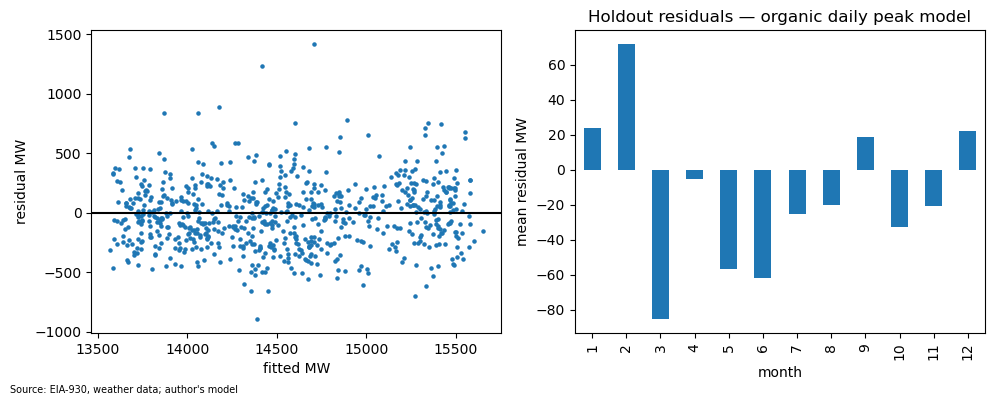

normal weather = average of 7 weather years 2019–2025; peak-day adjustment +563 MW
anchoring: peak scale 1.000, energy scale 1.000 (document if far from 1.0)
existing data centers held flat at 6,050 MW connected (as of 2025)
 year  organic_peak_mw  organic_peak_p90_mw  organic_energy_gwh  existing_dc_mw  baseline_peak_mw  baseline_energy_gwh
 2025          16223.0              16258.0            110621.0          6050.0           21063.0             153020.0
 2026          16329.0              16359.0            111590.0          6050.0           21169.0             153988.0
 2027          16447.0              16466.0            112558.0          6050.0           21287.0             154956.0
 2028          16548.0              16571.0            113856.0          6050.0           21388.0             156254.0
 2029          16653.0              16697.0            114498.0          6050.0           21493.0             156897.0
 2030          16769.0              16804.0            115467

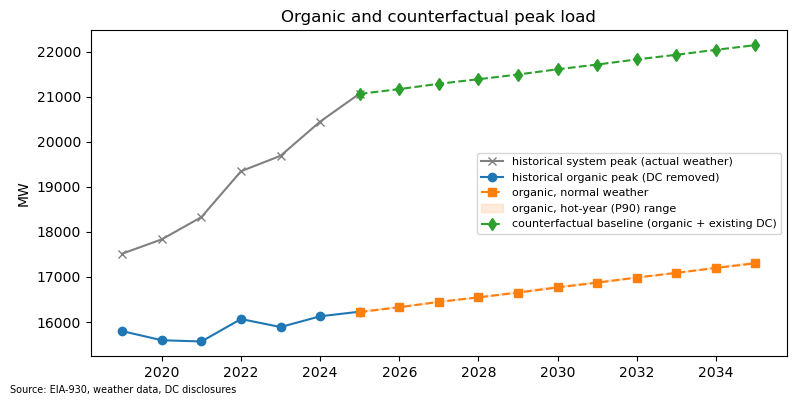

In [27]:
def _feats(df, B, hol_dates):
    df = df.copy()
    df["cdd"] = (df.tmean - B).clip(lower=0)
    df["hdd"] = (B - df.tmean).clip(lower=0)
    df["dow"] = df.date.dt.dayofweek
    df["hol"] = df.date.dt.date.isin(hol_dates).astype(int)
    df["t"] = (df.date - pd.Timestamp("2018-01-01")).dt.days / 365.25
    return df


def step_baseline(c):
    import holidays
    import statsmodels.formula.api as smf
    Y = years(c); B = c["degree_day_base_f"]; LF = c["dc_load_factor"]
    load = pd.read_parquet(P["raw"] / "load_hourly.parquet"); wx = pd.read_parquet(P["raw"] / "weather_hourly.parquet")
    d = pd.DataFrame({"peak_mw": load.load_mw.resample("D").max(), "energy_mwh": load.load_mw.resample("D").sum(),
                      "hours": load.load_mw.resample("D").count(), "tmean": wx.temp_f.resample("D").mean()}).dropna()
    d = d[d.hours >= 22].drop(columns="hours").reset_index().rename(columns={"period": "date"})
    d["year"] = d.date.dt.year
    if d.year.nunique() < 4:
        raise SystemExit("need at least 4 years of daily data for the train/holdout split")

    dc_series = load_dc_series(list(d.year.unique()) + Y + [c["base_year"]])
    d["dc_connected_mw"] = d.year.map(dc_series)
    d["organic_peak"] = d.peak_mw - d.dc_connected_mw * LF
    d["organic_energy"] = d.energy_mwh - d.dc_connected_mw * LF * 24
    if (d.organic_peak <= 0).any():
        raise SystemExit("organic_peak <= 0: DC series too large vs load — check units (MW, cumulative)")

    hol_dates = list(holidays.US(years=range(2015, 2041)).keys())
    d = _feats(d, B, hol_dates)
    d.to_parquet(P["interim"] / "daily.parquet")

    train, test = d[d.year <= c["train_end_year"]], d[d.year >= c["test_start_year"]]
    if len(train) < 365 or len(test) < 180:
        raise SystemExit(f"train={len(train)} test={len(test)} days — adjust train_end_year/test_start_year")
    FORM = "{y} ~ cdd + I(cdd**2) + hdd + I(hdd**2) + C(dow) + hol + t"
    m_peak = smf.ols(FORM.format(y="organic_peak"), train).fit()
    m_en = smf.ols(FORM.format(y="organic_energy"), train).fit()

    hist_idx = d.set_index("date")
    rows = []
    for name, m, col in [("peak", m_peak, "organic_peak"), ("energy", m_en, "organic_energy")]:
        naive = test.date.map(lambda x: hist_idx[col].get(x - pd.DateOffset(years=1), np.nan))
        trend_only = smf.ols(f"{col} ~ t", train).fit()
        rows.append({"target": name, "model_mape": mape(test[col], m.predict(test)),
                     "seasonal_naive_mape": mape(test[col], naive), "trend_only_mape": mape(test[col], trend_only.predict(test)),
                     "r2_train": m.rsquared, "trend_coef_per_yr": m.params["t"],
                     "trend_pct_per_yr": m.params["t"] / train[col].mean() * 100})
    val = pd.DataFrame(rows); val.to_csv(P["tab"] / "baseline_validation.csv", index=False)
    display(val.round(3))
    g = val.loc[val.target == "peak", "trend_pct_per_yr"].iloc[0]
    if not (0 <= g <= 2.5):
        print(f"WARNING: organic peak trend {g:.2f}%/yr is outside 0–2.5% — check the de-contamination series")

    # Peak-day bias: the max of fitted daily values sits below the actual annual max, because the actual peak day
    # also has a large positive residual. Measure that gap on TRAINING years and add it to annual peak predictions.
    def _annual_gap(df):
        g = df.assign(pred=m_peak.predict(df)).groupby("year").agg(actual=("organic_peak", "max"), pred=("pred", "max"))
        return (g.actual - g.pred)
    peak_adj_train = float(_annual_gap(train).mean())
    tp = test.assign(pred=m_peak.predict(test)).groupby("year").agg(actual=("organic_peak", "max"), pred=("pred", "max"))
    tp["pred_adj"] = tp.pred + peak_adj_train
    tp["ape_%"] = (tp.pred_adj - tp.actual).abs() / tp.actual * 100
    print(f"annual-peak adjustment (from training years): +{peak_adj_train:,.0f} MW")
    tp.to_csv(P["tab"] / "baseline_annual_peak_holdout.csv"); print(tp.round(1))

    res = test.organic_peak - m_peak.predict(test)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].scatter(m_peak.predict(test), res, s=5); ax[0].axhline(0, c="k")
    ax[0].set_xlabel("fitted MW"); ax[0].set_ylabel("residual MW")
    res.groupby(test.date.dt.month).mean().plot.bar(ax=ax[1]); ax[1].set_xlabel("month"); ax[1].set_ylabel("mean residual MW")
    savefig("baseline_residuals.png", "Holdout residuals — organic daily peak model", "EIA-930, weather data; author's model")

    # normal-weather projection: run every projection year through EACH historical weather year, then average.
    # (Averaging temperatures first would flatten the heat waves that set the annual peak.)
    peak_adj = float(_annual_gap(d).mean())          # use all history for the forecast itself
    d["doy"] = d.date.dt.dayofyear
    wx_years = [y for y, g in d.groupby("year") if len(g) >= 330]
    proj_dates = pd.DataFrame({"date": pd.date_range(f"{min(Y + [c['base_year']])}-01-01", f"{Y[-1]}-12-31", freq="D")})
    proj_dates["doy"] = proj_dates.date.dt.dayofyear.clip(upper=365)
    sims = []
    for wy in wx_years:
        temps = (d[d.year == wy].set_index("doy").tmean.reindex(range(1, 366))
                 .interpolate(limit_direction="both"))
        pj = proj_dates.assign(tmean=proj_dates.doy.map(temps))
        pj = _feats(pj, B, hol_dates); pj["year"] = pj.date.dt.year
        pj["peak_pred"] = m_peak.predict(pj); pj["energy_pred"] = m_en.predict(pj)
        sims.append(pj.groupby("year").agg(peak=("peak_pred", "max"), energy=("energy_pred", lambda s: s.sum() / 1000))
                    .assign(weather_year=wy))
    sims = pd.concat(sims).reset_index()
    sims["peak"] += peak_adj
    annual = sims.groupby("year").agg(organic_peak_mw=("peak", "mean"), organic_peak_p90_mw=("peak", lambda s: s.quantile(0.9)),
                                      organic_energy_gwh=("energy", "mean")).reset_index()
    print(f"normal weather = average of {len(wx_years)} weather years {wx_years[0]}–{wx_years[-1]}; "
          f"peak-day adjustment +{peak_adj:,.0f} MW")

    scale_p = scale_e = 1.0
    if c["anchor_to_base_year"] and not c["synthetic_mode"] and c["base_year"] in annual.year.values:
        target_p = c["peak_base_2024_mw"] - dc_series[c["base_year"]] * LF
        target_e = c["energy_base_2024_gwh"] - dc_series[c["base_year"]] * LF * 8.76
        scale_p = target_p / annual.loc[annual.year == c["base_year"], "organic_peak_mw"].iloc[0]
        scale_e = target_e / annual.loc[annual.year == c["base_year"], "organic_energy_gwh"].iloc[0]
    print(f"anchoring: peak scale {scale_p:.3f}, energy scale {scale_e:.3f} (document if far from 1.0)")
    annual["organic_peak_mw"] *= scale_p; annual["organic_peak_p90_mw"] *= scale_p; annual["organic_energy_gwh"] *= scale_e

    # existing DC = everything connected as of the LAST year in the DC history file. Projects already energized are
    # excluded from the pipeline overlay, so they must be in the counterfactual baseline — otherwise they'd vanish.
    dc_obs = pd.read_csv(P["raw"] / "dc_historical_connected_mw.csv").dropna(subset=["dc_connected_mw"])
    last_obs = int(min(dc_obs.year.max(), c["horizon_end"]))
    dc_exist = float(dc_series[last_obs])
    print(f"existing data centers held flat at {dc_exist:,.0f} MW connected (as of {last_obs})")
    annual["existing_dc_mw"] = dc_exist
    annual["baseline_peak_mw"] = annual.organic_peak_mw + dc_exist * LF
    annual["baseline_energy_gwh"] = annual.organic_energy_gwh + dc_exist * LF * 8.76
    annual = annual[annual.year.isin(Y)]
    annual.to_csv(P["tab"] / "baseline_annual.csv", index=False)

    hist = d.groupby("year").agg(organic_peak_mw=("organic_peak", "max"), system_peak_mw=("peak_mw", "max"),
                                 organic_energy_gwh=("organic_energy", lambda s: s.sum() / 1000)).reset_index()
    hist.to_csv(P["tab"] / "baseline_history.csv", index=False)
    print(annual.round(0).to_string(index=False))

    plt.figure(figsize=(8, 4))
    plt.plot(hist.year, hist.system_peak_mw, "x-", c="grey", label="historical system peak (actual weather)")
    plt.plot(hist.year, hist.organic_peak_mw, "o-", label="historical organic peak (DC removed)")
    plt.plot(annual.year, annual.organic_peak_mw, "s--", label="organic, normal weather")
    plt.fill_between(annual.year, annual.organic_peak_mw, annual.organic_peak_p90_mw, alpha=0.15, color="C1",
                     label="organic, hot-year (P90) range")
    plt.plot(annual.year, annual.baseline_peak_mw, "d--", label="counterfactual baseline (organic + existing DC)")
    plt.ylabel("MW"); plt.legend(fontsize=8)
    savefig("baseline_peak.png", "Organic and counterfactual peak load", "EIA-930, weather data, DC disclosures")


step_baseline(c)

## 5. Data-center pipeline: de-duplicate, funnel, Low/Base/High scenarios

rows: 40 → explicit dups removed: 0 → heuristic dups removed: 2 ['S009', 'S029'] → kept: 38
                         projects    mw
stage                                  
announced                      11  4000
zoned                           5  3200
interconnection_request         7  2500
esa_signed                      9  4200
construction                    5  2700
energized                       1   500


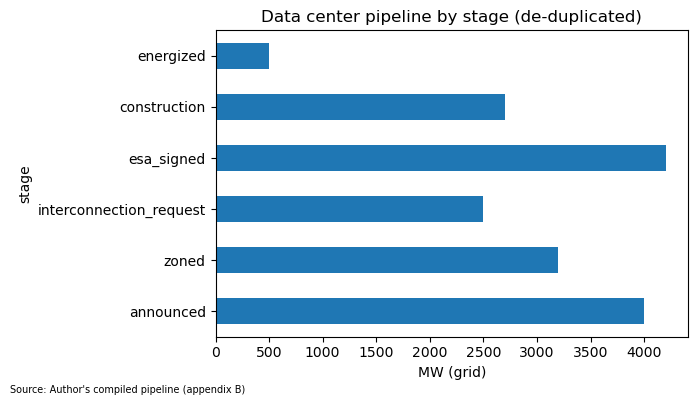

scenario     base     high     low
year                              
2025        150.0    400.0     0.0
2026        453.0    962.0   142.0
2027       1023.0   1835.0   502.0
2028       1972.0   3169.0  1151.0
2029       3178.0   4829.0  1982.0
2030       4754.0   6968.0  3082.0
2031       6730.0   9566.0  4516.0
2032       8488.0  11919.0  5767.0
2033       9807.0  13788.0  6642.0
2034      10362.0  14747.0  6907.0
2035      10734.0  15460.0  7044.0


In [28]:
def step_pipeline(c):
    Y = years(c); ORDER = {s: i for i, s in enumerate(STAGES)}
    pipe = pd.read_csv(P["proc"] / "pipeline.csv")
    pipe = pipe[~pipe.campus_name.astype(str).str.contains("EXAMPLE", case=False, na=False)].copy()
    if pipe.empty:
        raise SystemExit("pipeline.csv has no real rows — fill it in first")
    pipe["stage_raw"] = pipe.stage
    pipe["stage"] = pipe.stage.map(normalize_stage)
    bad = pipe[pipe.stage.isna()]
    if len(bad):
        raise SystemExit(f"Unrecognized stage values {bad.stage_raw.unique().tolist()} in rows {bad.project_id.tolist()}. Allowed: {STAGES}")
    pipe["capacity_mw_grid"] = pd.to_numeric(pipe.capacity_mw_grid, errors="coerce")
    pipe["capacity_mw_it"] = pd.to_numeric(pipe.capacity_mw_it, errors="coerce")
    pipe["capacity_mw_grid"] = pipe.capacity_mw_grid.fillna(pipe.capacity_mw_it * c["dc_pue_default"])
    pipe = pipe.dropna(subset=["capacity_mw_grid"])
    ann_year = pd.to_datetime(pipe.announced_date, errors="coerce").dt.year
    pipe["expected_cod"] = (pd.to_numeric(pipe.expected_cod, errors="coerce")
                            .fillna(ann_year + 3).fillna(c["base_year"] + 3).astype(int))
    pipe["developer"] = pipe.developer.fillna("UNKNOWN"); pipe["county"] = pipe.county.fillna("UNKNOWN")

    n_in = len(pipe)
    dup_col = pipe.duplicate_of if "duplicate_of" in pipe else pd.Series(np.nan, index=pipe.index)
    explicit = dup_col.notna() & (dup_col.astype(str).str.strip() != "")
    pipe = pipe[~explicit].copy()
    pipe["stage_rank"] = pipe.stage.map(ORDER)
    keep, dropped = [], []
    for (county, dev), g in pipe.groupby(["county", "developer"]):
        g = g.sort_values(["stage_rank", "capacity_mw_grid"], ascending=False)
        if dev == "UNKNOWN":          # can't infer duplicates without a developer
            keep += g.project_id.tolist(); continue
        kept = []
        for _, r in g.iterrows():
            if any(abs(r.capacity_mw_grid - k.capacity_mw_grid) / k.capacity_mw_grid < 0.20
                   and abs(r.expected_cod - k.expected_cod) <= 2 for k in kept):
                dropped.append(r.project_id); continue
            kept.append(r); keep.append(r.project_id)
    dedup = pipe[pipe.project_id.isin(keep)].copy()
    print(f"rows: {n_in} → explicit dups removed: {int(explicit.sum())} → heuristic dups removed: {len(dropped)} {dropped} → kept: {len(dedup)}")
    dedup.drop(columns=["stage_raw", "stage_rank"]).to_csv(P["proc"] / "pipeline_dedup.csv", index=False)

    funnel = dedup.groupby("stage").agg(projects=("project_id", "count"), mw=("capacity_mw_grid", "sum")).reindex(STAGES).fillna(0)
    funnel.to_csv(P["tab"] / "pipeline_funnel.csv"); print(funnel)
    funnel.mw.plot.barh(figsize=(7, 4)); plt.xlabel("MW (grid)")
    savefig("pipeline_funnel.png", "Data center pipeline by stage (de-duplicated)", "Author's compiled pipeline (appendix B)")

    ov = dedup[dedup.stage != "energized"] if c["exclude_energized_from_overlay"] else dedup
    rows = []
    for scen in ["low", "base", "high"]:
        prob = c["stage_prob"][scen]
        for y in Y:
            mw = sum(prob[r.stage] * r.capacity_mw_grid *
                     ramp_fraction(y, r.expected_cod + c["stage_delay_median_yrs"][r.stage], c["stage_ramp_yrs"][r.stage])
                     for r in ov.itertuples())
            mw += c["unannounced_mw_per_yr"][scen] * max(y - c["base_year"], 0)
            rows.append({"scenario": scen, "year": y, "dc_peak_mw": mw})
    sc = pd.DataFrame(rows); sc["dc_energy_gwh"] = sc.dc_peak_mw * 8.76 * c["dc_load_factor"]
    sc.to_csv(P["tab"] / "dc_scenarios.csv", index=False)
    print(sc.pivot(index="year", columns="scenario", values="dc_peak_mw").round(0))


step_pipeline(c)

## 6. Monte Carlo

          p5     p25      p50      p75      p95
year                                           
2025     0.0    83.0    150.0    218.0    320.0
2026   190.0   347.0    456.0    563.0    727.0
2027   596.0   889.0   1056.0   1213.0   1468.0
2028  1235.0  1701.0   1962.0   2232.0   2622.0
2029  2181.0  2768.0   3155.0   3555.0   4092.0
2030  3402.0  4149.0   4674.0   5171.0   5903.0
2031  4947.0  5874.0   6531.0   7158.0   8063.0
2032  6373.0  7494.0   8269.0   9018.0  10065.0
2033  7430.0  8689.0   9577.0  10398.0  11571.0
2034  7979.0  9340.0  10250.0  11143.0  12405.0
2035  8349.0  9748.0  10694.0  11604.0  12936.0


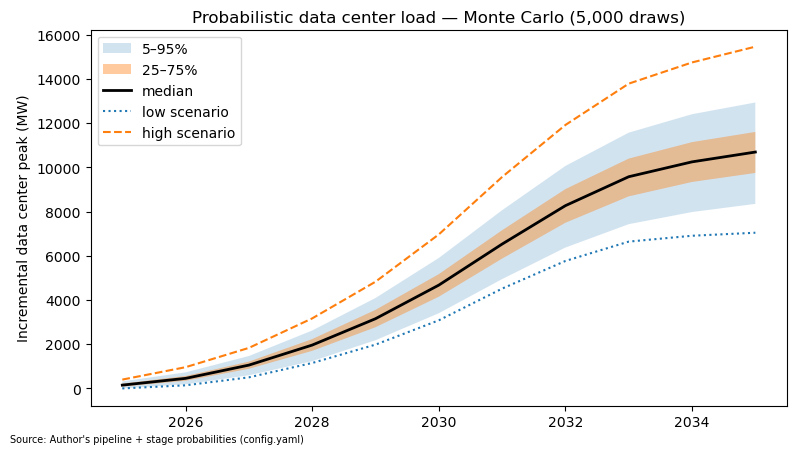

In [29]:
def step_mc(c):
    Y = years(c); rng = np.random.default_rng(c["seed"]); LF = c["dc_load_factor"]
    pipe = pd.read_csv(P["proc"] / "pipeline_dedup.csv")
    if c["exclude_energized_from_overlay"]:
        pipe = pipe[pipe.stage != "energized"]
    base = pd.read_csv(P["tab"] / "baseline_annual.csv").set_index("year").reindex(Y)
    if base.baseline_peak_mw.isna().any():
        raise SystemExit("baseline_annual.csv does not cover the full horizon — rerun baseline")
    cap = pipe.capacity_mw_grid.values.astype(float)
    p = pipe.stage.map(c["stage_prob"]["base"]).values.astype(float)
    dmed = pipe.stage.map(c["stage_delay_median_yrs"]).values.astype(float)
    ramp = pipe.stage.map(c["stage_ramp_yrs"]).values.astype(float)
    cod0 = pipe.expected_cod.values.astype(float); yrs = np.array(Y, float); N = c["mc_draws"]
    out = np.zeros((N, len(Y)))
    for i in range(N):
        built = rng.random(len(cap)) < p
        cod = cod0 + rng.lognormal(np.log(np.maximum(dmed, 0.1)), c["stage_delay_sigma"])
        frac = np.clip((yrs[None, :] + 1 - cod[:, None]) / np.maximum(ramp[:, None], 1e-6), 0, 1)
        out[i] = (cap * built) @ frac
        out[i] += np.cumsum(rng.normal(c["unannounced_mw_per_yr"]["base"], c["unannounced_sd"], len(Y)).clip(min=0)) * (yrs > c["base_year"])
    np.save(P["proc"] / "mc_draws.npy", out)
    pct = pd.DataFrame(np.percentile(out, [5, 25, 50, 75, 95], axis=0).T, index=pd.Index(Y, name="year"),
                       columns=["p5", "p25", "p50", "p75", "p95"])
    pct.to_csv(P["tab"] / "dc_fan.csv"); print(pct.round(0))

    sc = pd.read_csv(P["tab"] / "dc_scenarios.csv")

    def frame(name, dc_peak):
        dc_peak = np.asarray(dc_peak, float)
        return pd.DataFrame({"scenario": name, "year": Y, "baseline_peak_mw": base.baseline_peak_mw.values,
                             "dc_peak_mw": dc_peak, "total_peak_mw": base.baseline_peak_mw.values + dc_peak,
                             "baseline_energy_gwh": base.baseline_energy_gwh.values, "dc_energy_gwh": dc_peak * 8.76 * LF})
    frames = [frame(s, sc[sc.scenario == s].set_index("year").reindex(Y).dc_peak_mw.values) for s in ["low", "base", "high"]]
    frames += [frame(f"mc_{q}", pct[q].values) for q in ["p5", "p50", "p95"]]
    tot = pd.concat(frames); tot["total_energy_gwh"] = tot.baseline_energy_gwh + tot.dc_energy_gwh
    tot.to_csv(P["tab"] / "total_load_scenarios.csv", index=False)

    plt.figure(figsize=(8, 4.5))
    plt.fill_between(Y, pct.p5, pct.p95, alpha=0.2, label="5–95%")
    plt.fill_between(Y, pct.p25, pct.p75, alpha=0.4, label="25–75%")
    plt.plot(Y, pct.p50, "k-", lw=2, label="median")
    for s, ls in [("low", ":"), ("high", "--")]:
        plt.plot(Y, sc[sc.scenario == s].set_index("year").reindex(Y).dc_peak_mw.values, ls, label=f"{s} scenario")
    plt.ylabel("Incremental data center peak (MW)"); plt.legend()
    savefig("dc_fan_chart.png", f"Probabilistic data center load — Monte Carlo ({N:,} draws)",
            "Author's pipeline + stage probabilities (config.yaml)")


step_mc(c)

## 7. Capital → rate base → revenue requirement → rates → earnings

,variant,year,dc_peak_mw,total_peak_mw,cum_capex_bn,rate_base_bn,rate_cf_c_kwh,rate_sc_c_kwh,rate_delta_c_kwh,rate_delta_pct,d_net_income_mn
5,low,2030,3082.08,24690.89,23.75,20.91,9.49,10.65,1.17,12.28,1054.56
10,low,2035,7043.75,29188.16,56.88,44.54,10.74,12.81,2.07,19.31,2246.42
16,base,2030,4754.00,26362.80,36.45,31.88,9.49,11.16,1.67,17.57,1607.90
21,base,2035,10734.00,32878.41,86.67,67.90,10.74,13.55,2.82,26.23,3424.69
27,high,2030,6968.17,28576.97,53.20,46.23,9.49,11.72,2.23,23.55,2331.87
32,high,2035,15460.25,37604.66,124.74,97.65,10.74,14.29,3.55,33.11,4925.50
38,mc_p5,2030,3401.68,25010.48,26.20,23.06,9.49,10.76,1.27,13.38,1163.34
43,mc_p5,2035,8349.09,30493.49,67.84,53.68,10.74,13.13,2.40,22.34,2707.69
49,mc_p50,2030,4674.32,26283.12,35.82,31.30,9.49,11.13,1.64,17.30,1578.61
54,mc_p50,2035,10693.54,32837.94,86.48,67.94,10.74,13.56,2.82,26.29,3426.78


saved model_synthetic/capital_rate_model.xlsx


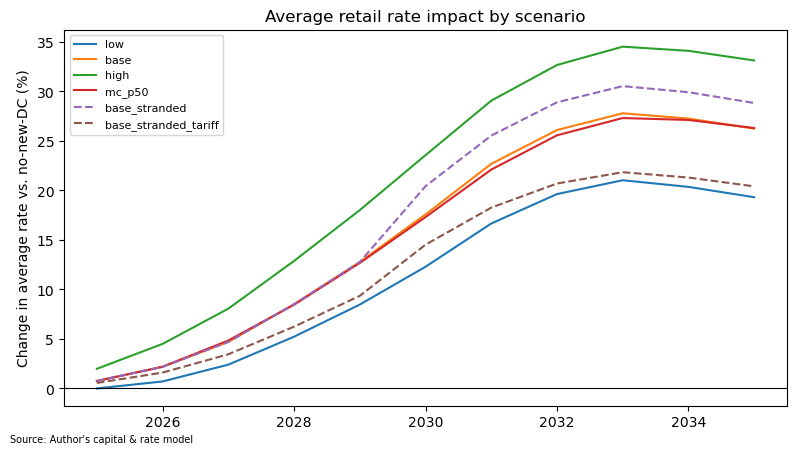

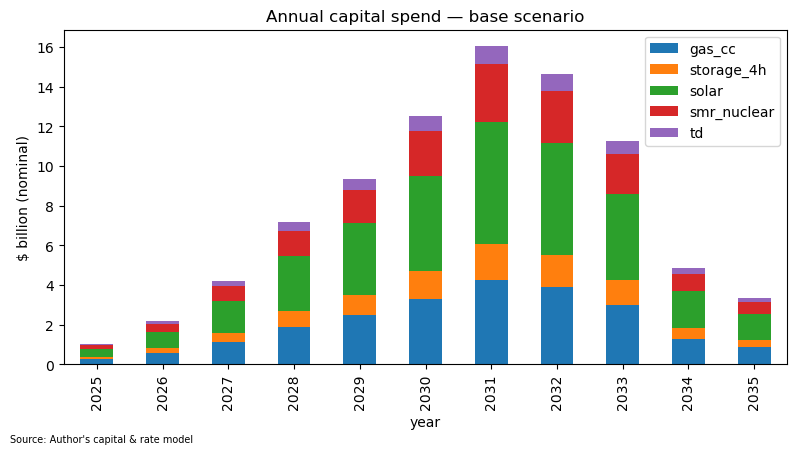

In [30]:
def run_model(dc_peak_mw, baseline_peak_mw, baseline_energy_gwh, c, tariff=False, stranded_share=0.0, overrides=None):
    """All three inputs are pd.Series indexed by year. dc_peak_mw = incremental vs counterfactual baseline."""
    c = {**c, **(overrides or {})}
    Y = list(dc_peak_mw.index); b = c["base_year"]; LF = c["dc_load_factor"]; infl = c["inflation"]
    ptw = c["equity_share"] * c["roe"] / (1 - c["tax_rate"]) + (1 - c["equity_share"]) * c["cost_of_debt"]  # pre-tax WACC
    ciac = c["tariff_ciac_share"] if tariff else c["ciac_share"]; capex_mult = c.get("capex_mult", 1.0)
    gross = {k: 0.0 for k in TECHS + ["td"]}; nameplate = {k: 0.0 for k in TECHS}
    rb = prev_dc = 0.0; rows = []
    for y in Y:
        n = y - b; inf = (1 + infl) ** n; dc = float(dc_peak_mw[y])
        build_for = max(dc, prev_dc)                      # capacity is never un-built
        stranded = (stranded_share * float(dc_peak_mw.get(c["stranded_year"], dc))
                    if (stranded_share and y >= c["stranded_year"]) else 0.0)
        served = max(dc - stranded, 0.0)
        add_peak = build_for - prev_dc; prev_dc = build_for
        accredited = add_peak * (1 + c["prm"])
        capex = {k: (accredited * c["resource_shares"][k] / c["elcc"][k]) * 1000 * c["capex_per_kw"][k] * inf * capex_mult for k in TECHS}
        for k in TECHS:
            nameplate[k] += accredited * c["resource_shares"][k] / c["elcc"][k]
        capex["td"] = add_peak * 1000 * c["td_capex_per_kw_peak"] * inf * capex_mult
        capex_total = sum(capex.values())
        for k in capex:
            gross[k] += capex[k] * (1 - ciac)
        dep = sum(gross[k] / c["book_life_yrs"][k] for k in gross)
        rb = max(rb + capex_total * (1 - ciac) - dep, 0.0)
        fom = sum(nameplate[k] * 1000 * c["fom_per_kw_yr"][k] * inf for k in TECHS)
        dc_mwh = served * 8760 * LF; fuel = dc_mwh * c["marginal_energy_cost_per_mwh"] * inf
        d_rr = rb * ptw + dep + fom + fuel
        min_bill = stranded * 1000 * c["demand_charge_per_kw_month"] * 12 * c["tariff_min_take"] * inf if tariff else 0.0
        e_cf = float(baseline_energy_gwh[y]) * 1000
        rr_cf = c["rr_base_2024_usd"] * inf * (e_cf / (c["energy_base_2024_gwh"] * 1000))
        rate_cf = rr_cf / e_cf * 0.1                                     # ¢/kWh
        rate_sc = (rr_cf + d_rr - min_bill) / (e_cf + dc_mwh) * 0.1
        rows.append(dict(year=y, baseline_peak_mw=float(baseline_peak_mw[y]), dc_peak_mw=dc, stranded_mw=stranded,
                         total_peak_mw=float(baseline_peak_mw[y]) + served, accredited_add_mw=accredited,
                         capex_total_usd=capex_total, **{f"capex_{k}_usd": v for k, v in capex.items()},
                         rate_base_usd=rb, depreciation_usd=dep, fom_usd=fom, fuel_usd=fuel, d_rr_usd=d_rr,
                         min_bill_usd=min_bill, rr_cf_usd=rr_cf, rate_cf_c_kwh=rate_cf, rate_sc_c_kwh=rate_sc,
                         rate_delta_c_kwh=rate_sc - rate_cf, rate_delta_pct=(rate_sc / rate_cf - 1) * 100,
                         d_net_income_usd=rb * c["equity_share"] * c["roe"]))
    return pd.DataFrame(rows)


def _scenario_inputs(c):
    Y = years(c)
    tot = pd.read_csv(P["tab"] / "total_load_scenarios.csv")
    base = pd.read_csv(P["tab"] / "baseline_annual.csv").set_index("year").reindex(Y)
    dc = {s: g.set_index("year").reindex(Y).dc_peak_mw for s, g in tot.groupby("scenario")}
    return base, dc


def all_variants(c, base, dc, overrides=None):
    variants = {s: dict(dc=dc[s], tariff=False, stranded=0.0) for s in ["low", "base", "high", "mc_p5", "mc_p50", "mc_p95"] if s in dc}
    variants["base_stranded"] = dict(dc=dc["base"], tariff=False, stranded=c["stranded_share"])
    variants["base_stranded_tariff"] = dict(dc=dc["base"], tariff=True, stranded=c["stranded_share"])
    out = []
    for name, v in variants.items():
        r = run_model(v["dc"], base.baseline_peak_mw, base.baseline_energy_gwh, c, tariff=v["tariff"],
                      stranded_share=v["stranded"], overrides=overrides)
        r.insert(0, "variant", name); out.append(r)
    res = pd.concat(out, ignore_index=True)
    res["cum_capex_usd"] = res.groupby("variant").capex_total_usd.cumsum()
    return res


def step_model(c):
    base, dc = _scenario_inputs(c)
    res = all_variants(c, base, dc)
    res.to_csv(P["tab"] / "model_results.csv", index=False)
    ry = [y for y in c["report_years"] if y in res.year.values] or [res.year.max()]
    head = res[res.year.isin(ry)].assign(
        cum_capex_bn=lambda d: d.cum_capex_usd / 1e9, rate_base_bn=lambda d: d.rate_base_usd / 1e9,
        d_net_income_mn=lambda d: d.d_net_income_usd / 1e6)[
        ["variant", "year", "dc_peak_mw", "total_peak_mw", "cum_capex_bn", "rate_base_bn",
         "rate_cf_c_kwh", "rate_sc_c_kwh", "rate_delta_c_kwh", "rate_delta_pct", "d_net_income_mn"]]
    head.to_csv(P["tab"] / "headline_table.csv", index=False)
    display(head.round(2))

    xl = P["model"] / "capital_rate_model.xlsx"
    try:
        flat = pd.json_normalize({k: v for k, v in c.items() if k != "eia_api_key"}, sep=".").T.reset_index()
        flat.columns = ["assumption", "value"]; flat["value"] = flat.value.astype(str)
        with pd.ExcelWriter(xl) as w:
            if c["synthetic_mode"]:
                pd.DataFrame({"WARNING": ["SYNTHETIC DATA — NOT FOR REPORTING"]}).to_excel(w, sheet_name="README", index=False)
            flat.to_excel(w, sheet_name="Assumptions", index=False)
            pd.read_csv(P["tab"] / "total_load_scenarios.csv").to_excel(w, sheet_name="Load_Scenarios", index=False)
            head.to_excel(w, sheet_name="Headline", index=False)
            for v, g in res.groupby("variant", sort=False):
                g.to_excel(w, sheet_name=v[:31], index=False)
        print(f"saved {xl.relative_to(ROOT)}")
    except Exception as e:
        print(f"(Excel export skipped: {e})")

    plt.figure(figsize=(8, 4.5))
    for v, g in res.groupby("variant", sort=False):
        if v in ("mc_p5", "mc_p95"):
            continue
        plt.plot(g.year, g.rate_delta_pct, label=v, ls="--" if "stranded" in v else "-")
    plt.axhline(0, c="k", lw=0.8); plt.ylabel("Change in average rate vs. no-new-DC (%)"); plt.legend(fontsize=8)
    savefig("rate_impact.png", "Average retail rate impact by scenario", "Author's capital & rate model")

    b = res[res.variant == "base"].set_index("year")
    cols = [f"capex_{k}_usd" for k in TECHS + ["td"]]
    (b[cols] / 1e9).rename(columns=lambda s: s.replace("capex_", "").replace("_usd", "")).plot.bar(stacked=True, figsize=(8, 4.5))
    plt.ylabel("$ billion (nominal)")
    savefig("capex_by_tech.png", "Annual capital spend — base scenario", "Author's capital & rate model")


step_model(c)

## 8. Sensitivity (tornado)

rate impact 2035, base = 26.23%


,driver,base_value,low_input,high_input,swing
0,T&D $/kW ±50%,26.23,25.26,27.20,1.94
1,Reserve margin ±5pt,26.23,24.59,27.88,3.29
2,Inflation 1.5% / 4%,26.23,27.68,24.22,3.46
3,ROE ±100bp,26.23,24.39,28.08,3.69
4,DC load factor 0.65 / 0.90,26.23,30.72,23.52,7.20
5,CIAC share 0% / 25%,26.23,28.08,18.86,9.22
6,Energy cost ±30%,26.23,21.02,31.45,10.43
7,DC load: low / high scenario,26.23,19.31,33.11,13.81
8,Capex ±20%,26.23,19.23,33.24,14.01


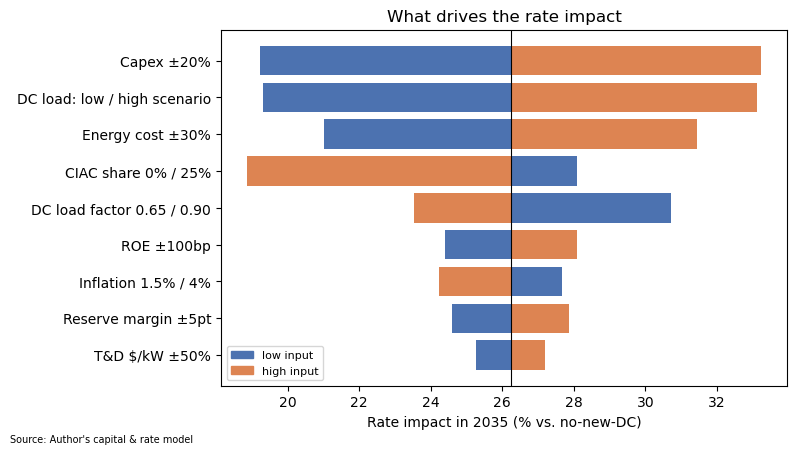

In [31]:
def step_sens(c):
    base, dc = _scenario_inputs(c)
    yr = c["horizon_end"]

    def metric(overrides=None, scen="base"):
        r = run_model(dc[scen], base.baseline_peak_mw, base.baseline_energy_gwh, c, overrides=overrides)
        return float(r.set_index("year").loc[yr, "rate_delta_pct"])

    center = metric()
    tests = [
        ("Capex ±20%", {"capex_mult": 0.8}, {"capex_mult": 1.2}),
        ("ROE ±100bp", {"roe": c["roe"] - 0.01}, {"roe": c["roe"] + 0.01}),
        ("Reserve margin ±5pt", {"prm": c["prm"] - 0.05}, {"prm": c["prm"] + 0.05}),
        ("DC load factor 0.65 / 0.90", {"dc_load_factor": 0.65}, {"dc_load_factor": 0.90}),
        ("CIAC share 0% / 25%", {"ciac_share": 0.0}, {"ciac_share": 0.25}),
        ("Energy cost ±30%", {"marginal_energy_cost_per_mwh": c["marginal_energy_cost_per_mwh"] * 0.7},
         {"marginal_energy_cost_per_mwh": c["marginal_energy_cost_per_mwh"] * 1.3}),
        ("T&D $/kW ±50%", {"td_capex_per_kw_peak": c["td_capex_per_kw_peak"] * 0.5},
         {"td_capex_per_kw_peak": c["td_capex_per_kw_peak"] * 1.5}),
        ("Inflation 1.5% / 4%", {"inflation": 0.015}, {"inflation": 0.04}),
    ]
    rows = [{"driver": n, "low_input": metric(lo), "high_input": metric(hi)} for n, lo, hi in tests]
    rows.append({"driver": "DC load: low / high scenario", "low_input": metric(scen="low"), "high_input": metric(scen="high")})
    t = pd.DataFrame(rows)
    t["swing"] = (t.high_input - t.low_input).abs()
    t = t.sort_values("swing").reset_index(drop=True)
    t.insert(1, "base_value", center)
    t.to_csv(P["tab"] / "sensitivity_tornado.csv", index=False)
    print(f"rate impact {yr}, base = {center:.2f}%"); display(t.round(2))

    plt.figure(figsize=(8, 4.5))
    for i, r in t.iterrows():
        lo, hi = r.low_input - center, r.high_input - center
        plt.barh(i, lo, left=center, color="#4c72b0"); plt.barh(i, hi, left=center, color="#dd8452")
    plt.yticks(range(len(t)), t.driver); plt.axvline(center, c="k", lw=0.8)
    plt.xlabel(f"Rate impact in {yr} (% vs. no-new-DC)")
    plt.legend(handles=[plt.Rectangle((0, 0), 1, 1, color="#4c72b0"), plt.Rectangle((0, 0), 1, 1, color="#dd8452")],
               labels=["low input", "high input"], fontsize=8)
    savefig("sensitivity_tornado.png", "What drives the rate impact", "Author's capital & rate model")


step_sens(c)

## 9. Benchmark against official forecasts

            source  vintage      metric  year  external  model_base  model_p5  model_p95  diff_pct  within_p5_p95
SYNTHETIC official     2025 summer_peak  2030   27000.0     26362.8   25010.5    27511.7      -2.4           True
SYNTHETIC official     2025 summer_peak  2035   33000.0     32878.4   30493.5    35079.9      -0.4           True


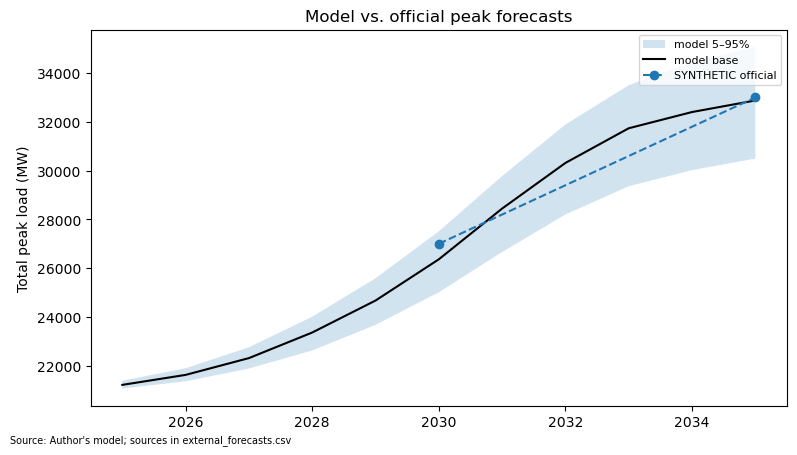

In [32]:
def step_bench(c):
    ext = pd.read_csv(P["raw"] / "external_forecasts.csv")
    ext = ext[pd.to_numeric(ext.get("value_mw"), errors="coerce").notna()] if "value_mw" in ext else ext.iloc[0:0]
    out_path = P["tab"] / "benchmark.csv"
    if ext.empty:
        pd.DataFrame(columns=["source", "vintage", "metric", "year", "external", "model_base", "model_p5", "model_p95",
                              "diff_pct", "within_p5_p95"]).to_csv(out_path, index=False)
        print("no external forecasts yet — wrote empty benchmark.csv"); return
    tot = pd.read_csv(P["tab"] / "total_load_scenarios.csv")
    col = {"summer_peak": "total_peak_mw", "peak": "total_peak_mw", "energy": "total_energy_gwh", "annual_energy": "total_energy_gwh"}
    piv = {m: tot.pivot(index="year", columns="scenario", values=v) for m, v in set(col.items())}
    rows = []
    for r in ext.itertuples():
        m = str(r.metric).strip().lower()
        if m not in col or int(r.year) not in piv[m].index:
            print(f"  skipping {r.source} {r.metric} {r.year} (unknown metric or outside horizon)"); continue
        p = piv[m].loc[int(r.year)]
        rows.append(dict(source=r.source, vintage=r.vintage, metric=m, year=int(r.year), external=float(r.value_mw),
                         model_base=p["base"], model_p5=p.get("mc_p5"), model_p95=p.get("mc_p95"),
                         diff_pct=(p["base"] / float(r.value_mw) - 1) * 100,
                         within_p5_p95=bool(p.get("mc_p5") <= float(r.value_mw) <= p.get("mc_p95"))))
    b = pd.DataFrame(rows); b.to_csv(out_path, index=False); print(b.round(1).to_string(index=False))

    pk = tot.pivot(index="year", columns="scenario", values="total_peak_mw")
    plt.figure(figsize=(8, 4.5))
    plt.fill_between(pk.index, pk.mc_p5, pk.mc_p95, alpha=0.2, label="model 5–95%")
    plt.plot(pk.index, pk.base, "k-", label="model base")
    e = b[b.metric.isin(["summer_peak", "peak"])]
    for s, g in e.groupby("source"):
        plt.plot(g.year, g.external, "o--", label=s)
    plt.ylabel("Total peak load (MW)"); plt.legend(fontsize=8)
    savefig("benchmark_peak.png", "Model vs. official peak forecasts", "Author's model; sources in external_forecasts.csv")


step_bench(c)

## Done

In [33]:
print("Tables :", P["tab"])
print("Figures:", P["fig"])
print("Excel  :", P["model"])
if c["synthetic_mode"]:
    print("\nThese are SYNTHETIC results — for testing only. Set SYNTHETIC = False for the real run.")
display(pd.read_csv(P["tab"] / "headline_table.csv").round(2))

Tables : /Users/opdime/Projects/dominionenergy_forecast/outputs_synthetic/tables
Figures: /Users/opdime/Projects/dominionenergy_forecast/outputs_synthetic/figures
Excel  : /Users/opdime/Projects/dominionenergy_forecast/model_synthetic

These are SYNTHETIC results — for testing only. Set SYNTHETIC = False for the real run.


,variant,year,dc_peak_mw,total_peak_mw,cum_capex_bn,rate_base_bn,rate_cf_c_kwh,rate_sc_c_kwh,rate_delta_c_kwh,rate_delta_pct,d_net_income_mn
0,low,2030,3082.08,24690.89,23.75,20.91,9.49,10.65,1.17,12.28,1054.56
1,low,2035,7043.75,29188.16,56.88,44.54,10.74,12.81,2.07,19.31,2246.42
2,base,2030,4754.00,26362.80,36.45,31.88,9.49,11.16,1.67,17.57,1607.90
3,base,2035,10734.00,32878.41,86.67,67.90,10.74,13.55,2.82,26.23,3424.69
4,high,2030,6968.17,28576.97,53.20,46.23,9.49,11.72,2.23,23.55,2331.87
5,high,2035,15460.25,37604.66,124.74,97.65,10.74,14.29,3.55,33.11,4925.50
6,mc_p5,2030,3401.68,25010.48,26.20,23.06,9.49,10.76,1.27,13.38,1163.34
7,mc_p5,2035,8349.09,30493.49,67.84,53.68,10.74,13.13,2.40,22.34,2707.69
8,mc_p50,2030,4674.32,26283.12,35.82,31.30,9.49,11.13,1.64,17.30,1578.61
9,mc_p50,2035,10693.54,32837.94,86.48,67.94,10.74,13.56,2.82,26.29,3426.78


### Optional: delete derived outputs (raw data and pipeline.csv are kept)
Uncomment and run only if you want a clean rerun.

In [34]:
def step_clean(c):
    for key in ["interim", "fig", "tab"]:
        shutil.rmtree(P[key], ignore_errors=True); P[key].mkdir(parents=True, exist_ok=True)
    for f in ["pipeline_dedup.csv", "mc_draws.npy"]:
        (P["proc"] / f).unlink(missing_ok=True)
    print("cleaned derived files (raw data and pipeline.csv kept)")


# step_clean(c)